<h2 align="center">How are in-demand skills trending for Data Engineers in India?</h2>

In [1]:
# importing the libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# loading the dataset
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

# sorting by date
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])

# converting job_skills from string to list
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])

c:\Users\mrpra\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [47]:
# selecting the data for Data Engineers in India
df_DA_IN = df[(df['job_title_short']=='Data Engineer')&(df['job_country']=='India')].copy()
df_DA_IN['month_number'] = df_DA_IN['job_posted_date'].dt.month

# now exploding the jobs_skills
df_DA_IN = df_DA_IN.explode('job_skills')

# now creating a pivot table based on month_number
df_DA_IN_pivot = df_DA_IN.pivot_table(index='month_number',columns='job_skills',aggfunc='size',fill_value=0)

# now lets create a new row using loc function
df_DA_IN_pivot.loc['Total'] = df_DA_IN_pivot.sum()

# sorting by order
df_DA_IN_pivot = df_DA_IN_pivot[df_DA_IN_pivot.loc['Total'].sort_values(ascending=False).index]

# now drop 'Total' row
df_DA_IN_pivot = df_DA_IN_pivot.drop('Total')
df_DA_IN_pivot


job_skills,sql,python,spark,aws,azure,java,hadoop,scala,databricks,kafka,...,dplyr,electron,heroku,ggplot2,mlpack,sass,symfony,sqlserver,solidity,wrike
month_number,,,,,,,,,,,,,,,,,,,,,
1,1459,1320,834,759,765,470,501,419,372,406,...,0,0,0,0,1,0,0,0,0,0
2,1133,994,655,582,553,385,424,303,280,320,...,0,0,0,0,0,1,0,1,0,0
3,1073,980,615,592,527,349,312,294,290,320,...,0,0,0,0,0,0,0,0,0,0
4,1072,926,614,567,522,358,329,280,283,310,...,1,0,0,0,0,0,0,0,0,0
5,915,829,548,514,468,294,297,265,256,281,...,0,0,0,0,0,0,0,0,0,0
6,1116,974,644,602,596,336,338,343,304,318,...,0,0,0,0,0,0,0,0,0,0
7,1052,901,527,569,593,291,287,278,267,264,...,0,1,0,0,0,0,0,0,0,0
8,935,798,510,534,485,287,271,272,256,269,...,0,0,0,1,0,0,0,0,1,0
9,996,886,509,529,533,306,299,315,290,265,...,0,0,0,0,0,0,1,0,0,0


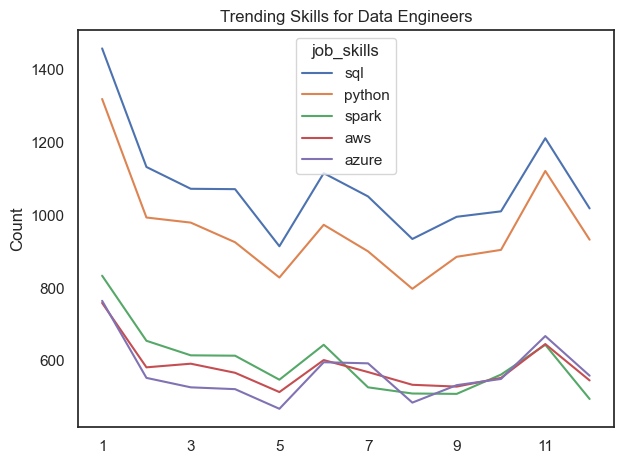

In [44]:
# now lets try to plot this 
df_DA_IN_pivot.iloc[:,:5].plot(kind='line')
plt.title('Trending Skills for Data Engineers')
plt.xlabel('')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [45]:
# now to create the likelihood of the skill occuring on different months can be calculated by dividing each month with total skills asked in that month
DA_total = df_DA_IN.groupby('month_number').size()
DA_IN_percent = df_DA_IN_pivot.iloc[:12].div(DA_total, axis=0)*100

# now lets convert the month number to month name
DA_IN_percent = DA_IN_percent.reset_index()
DA_IN_percent['month_name'] = DA_IN_percent['month_number'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
DA_IN_percent = DA_IN_percent.set_index('month_name')
DA_IN_percent = DA_IN_percent.drop(columns='month_number')

DA_IN_percent.iloc[:,:5]

job_skills,sql,python,spark,aws,azure
month_name,,,,,
Jan,9.845469,8.907484,5.627910,5.121803,5.162292
Feb,9.866760,8.656274,5.704084,5.068362,4.815815
Mar,9.774094,8.926945,5.602113,5.392603,4.800510
Apr,10.098917,8.723504,5.784268,5.341498,4.917569
May,9.798672,8.877704,5.868494,5.504391,5.011780
Jun,10.028756,8.752696,5.787203,5.409777,5.355859
Jul,10.472872,8.969637,5.246391,5.664510,5.903435
Aug,9.891040,8.441765,5.395113,5.649000,5.130646
Sep,10.387985,9.240718,5.308719,5.517313,5.559032


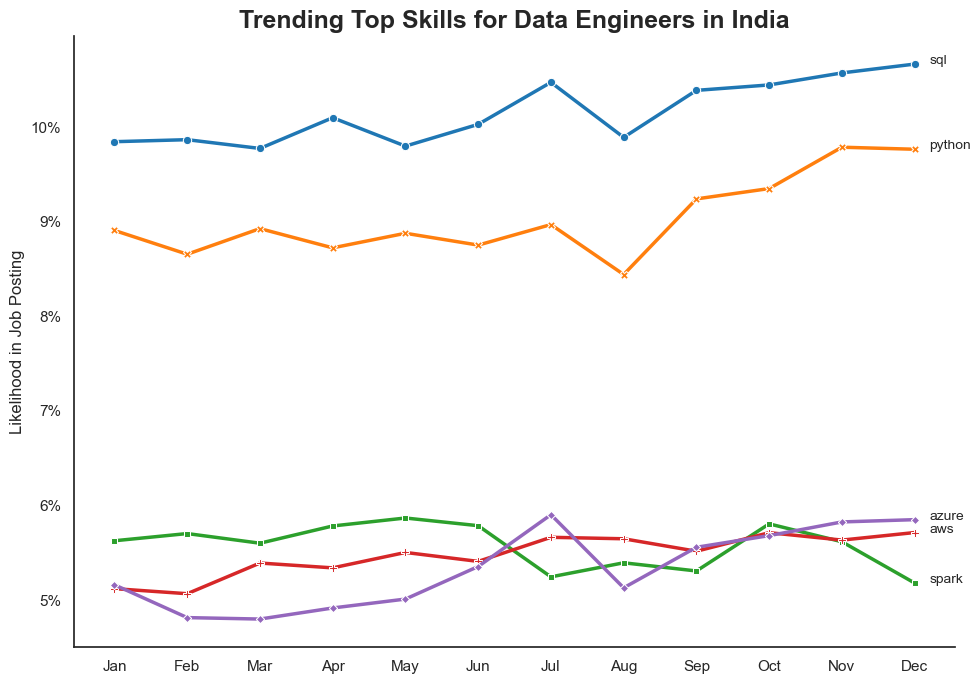

In [46]:
from matplotlib.ticker import PercentFormatter

# theme first
sns.set_theme(style='white')

plt.figure(figsize=(10,7))

df_plot = DA_IN_percent.iloc[:, :5]

sns.lineplot(
    data=df_plot,
    dashes=False,
    palette="tab10",
    linewidth=2.5,
    markers=True
)

plt.title('Trending Top Skills for Data Engineers in India', fontsize=18, weight='bold')
plt.ylabel('Likelihood in Job Posting')
plt.xlabel('')

plt.gca().yaxis.set_major_formatter(PercentFormatter(decimals=0))
sns.despine()

# annotate the plot with the top 5 skills
for i in range(5):
    plt.text(11.2, df_plot.iloc[-1, i], df_plot.columns[i], fontsize=10)

plt.legend().remove()

plt.tight_layout()
plt.show()